In [1]:
import sys
sys.path.append("..")

In [2]:
from pipeline.ingesta import cargar_indices_desde_bd, cargar_clima_desde_bd
from utils.conexionDB import set_db_mode
from utils.graficas import *
from utils.aplicar_whittaker import aplicar_whittaker_series
from pipeline.modulo_fenologico import segmentar_ciclos
import numpy as np
set_db_mode("pruebas")  # <===================IMPORTANTE CAMBIA A LA BD DE PRUEBAS======================================

2026-07-11 12:51:37.906 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-11 12:51:37.908 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-11 12:51:37.909 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-11 12:51:37.910 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-11 12:51:37.911 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-11 12:51:37.912 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-11 12:51:37.913 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-11 12:51:37.914 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-

  📁 Modo BD cambiado a: PRUEBAS (c:\Users\mayno\Desktop\SeminarioInvestigacion\segmentacion_clasificacion_estimacion_maiz_comayagua\notebooks\..\data\pipeline_pruebas.gpkg)


In [3]:
temp_ext = ["2025-01-01","2026-07-11"]

In [11]:
graficar_whittaker_sos(temp_ext[0],temp_ext[1], distancia_min_dias=70, prominencia_min=0.05)

✅  Índices cargados desde BD: 533 fechas × 19 parcelas (2025-01-01 → 2026-07-09).
📈 Suavizando serie temporal para: EVI...
📈 Suavizando serie temporal para: LSWI...

🌾 Calculando FPAR y Factor de Estrés Hídrico Diario (W_scalar)...

✅ Métricas base del VPM calculadas y consolidadas a nivel DIARIO:
   ✔️ Total de Parcelas Procesadas: 19
   ✔️ FPAR Diario (Máx Global): 0.987
   ✔️ W_scalar Diario (Mín/Máx Global): 0.663 / 1.000


interactive(children=(Dropdown(description='🌱 Parcela:', options=('id_0', 'id_1', 'id_10', 'id_11', 'id_12', '…

In [4]:
dfs_indices = cargar_indices_desde_bd(temp_ext[0],temp_ext[1])

✅  Índices cargados desde BD: 533 fechas × 19 parcelas (2025-01-01 → 2026-07-09).


In [5]:
def procesar_indice(df_indice, lambda_param=4000, rango_valido=(-1.0, 1.0)):
    df = df_indice.mask((df_indice < rango_valido[0]) | (df_indice > rango_valido[1]), np.nan)
    rango_diario = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
    df = df.reindex(rango_diario)
    df_suavizado = aplicar_whittaker_series({"INDICE": df}, lambda_param=lambda_param)
    return df_suavizado["INDICE"]

df_evi = procesar_indice(dfs_indices["EVI"].copy())
df_lswi = procesar_indice(dfs_indices["LSWI"].copy())

📈 Suavizando serie temporal para: INDICE...
📈 Suavizando serie temporal para: INDICE...


In [8]:
segmentos_por_parcela: dict[int, list[tuple[pd.Timestamp, pd.Timestamp]]] = {}

for col in df_evi.columns:
    try:
        id_parcela = int(col.split("_")[1])
    except (IndexError, ValueError):
        continue

    serie = df_evi[col].dropna()
    if serie.empty:
        continue

    segmentos = segmentar_ciclos(
        serie=serie,
        distancia_min_dias=70,
        prominencia_min=0.05,
    )
    segmentos_por_parcela[id_parcela] = segmentos

In [9]:
sos_por_segmento: dict[int, list[dict]] = {}
ciclos_creados = 0

for id_parcela, segmentos in segmentos_por_parcela.items():
    col = f"id_{id_parcela}"
    if col not in df_evi.columns:
        continue

    lista_resultados = []
    for inicio, fin in segmentos:
        serie_seg = df_evi.loc[inicio:fin, col].dropna()
        if serie_seg.empty:
            continue

        resultado = detectar_sos(
            serie=serie_seg.values,
            fechas=serie_seg.index,
            factor=0.2,
            ventana_busqueda=(inicio, fin),
        )
        resultado["inicio_segmento"] = inicio
        resultado["fin_segmento"] = fin
        lista_resultados.append(resultado)

        sos_fecha = resultado.get("sos_fecha")
        if sos_fecha is not None:
                ciclos_creados += 1

    if lista_resultados:
            sos_por_segmento[id_parcela] = lista_resultados

In [10]:
# Celda — Conteo de ciclos detectados (ya cerrados por diseño de segmentar_ciclos)

resultados_validados = []
for id_parcela, lista_resultados in sos_por_segmento.items():
    for r in lista_resultados:
        if r.get("sos_fecha") is None:
            continue
        r["id_parcela"] = id_parcela
        r["duracion_dias"] = (r["fin_segmento"] - r["sos_fecha"]).days
        resultados_validados.append(r)

df_ciclos_detectados = pd.DataFrame(resultados_validados)

print(f"Total de ciclos detectados con SOS y cierre confirmado: {len(df_ciclos_detectados)}")
print(f"Parcelas distintas representadas: {df_ciclos_detectados['id_parcela'].nunique()}")
print()
print("Distribución de duración de ciclo (días):")
print(df_ciclos_detectados["duracion_dias"].describe())
print()
print(df_ciclos_detectados[["id_parcela", "sos_fecha", "fin_segmento", "duracion_dias"]].sort_values(["id_parcela", "sos_fecha"]))

Total de ciclos detectados con SOS y cierre confirmado: 44
Parcelas distintas representadas: 19

Distribución de duración de ciclo (días):
count     44.000000
mean     128.363636
std       54.227810
min       62.000000
25%       96.500000
50%      114.000000
75%      144.750000
max      312.000000
Name: duracion_dias, dtype: float64

    id_parcela  sos_fecha fin_segmento  duracion_dias
0            0 2025-06-02   2025-10-09            129
1            0 2025-11-06   2026-03-11            125
2            1 2025-05-27   2025-07-31             65
3            1 2025-09-01   2026-03-05            185
22           2 2025-04-27   2025-09-29            155
23           2 2025-12-08   2026-04-03            116
24           3 2025-04-27   2025-09-26            152
25           3 2025-12-08   2026-04-01            114
26           4 2025-04-27   2025-09-28            154
27           4 2025-12-12   2026-04-08            117
28           5 2025-04-27   2025-09-27            153
29           5 2

In [ ]:
# Celda — Tabla de correcciones manuales (override sobre el cruce automático)

correcciones_manuales = pd.DataFrame([
    {
        "id_parcela": 10,
        "sos_confirmado": pd.Timestamp("2025-08-26"),
        "fin_confirmado": pd.Timestamp("2025-12-22"),
        "origen_etiqueta": "confirmado_campo_fecha_invalida",
        "justificacion": (
            "Fecha de siembra/cosecha reportada de memoria por el productor"
            "Se usa el segmento detectado por segmentar_ciclos (campana limpia sin ruido "
            "confirmada visualmente). HIPOTESIS: de los 3 segmentos detectados para esta "
            "parcela, se elige este por ser el que mejor calza con la ventana calendario "
            "de postrera (ago-mar) y con la duracion reportada (~117d vs 115d detectados). "
        ),
    },
    {
        "id_parcela": 11,
        "sos_confirmado": pd.Timestamp("2025-08-21"),
        "fin_confirmado": pd.Timestamp("2025-12-22"),
        "origen_etiqueta": "confirmado_campo_fecha_invalida",
        "justificacion": (
            "Mismo caso que id_10 (mismo productor, misma fecha reportada de memoria). "
            "Segmento elegido por ventana postrera + duracion consistente (112d). "
        ),
    },
    {
        "id_parcela": 14,
        "sos_confirmado": pd.Timestamp("2025-06-07"),
        "fin_confirmado": pd.Timestamp("2025-10-17"),
        "origen_etiqueta": "ciclo_sin_valle_cierre",
        "justificacion": (
            "Ciclo sin valle de cierre detectado, pero con valores claramente llegando a tierra desnuda."
        ),
    },
    {
        "id_parcela": 15,
        "sos_confirmado": pd.Timestamp("2025-06-18"),
        "fin_confirmado": pd.Timestamp("2025-10-31"),  # truncado a cosecha de campo, no al cierre detectado (312d)
        "origen_etiqueta": "confirmado_dicta_truncado_manual",
        "justificacion": (
            "Segmento detectado (312d) fusiona multiples eventos por valle de baja "
            "prominencia cerca de la fecha de cosecha reportada. Se trunca manualmente "
            "usando fecha_cosecha_campo como cierre, en vez del cierre real detectado."
        ),
    },
    {
        "id_parcela": 16,
        "sos_confirmado": pd.Timestamp("2025-07-07"),
        "fin_confirmado": pd.Timestamp("2025-11-22"),  # truncado a cosecha de campo, no al cierre detectado (242d)
        "origen_etiqueta": "confirmado_dicta_truncado_manual",
        "justificacion": "Mismo caso que id_15: se trunca a fecha de cosecha de campo.",
    },
    {
        "id_parcela": 18,
        "sos_confirmado": pd.Timestamp("2025-04-16"),
        "fin_confirmado": pd.Timestamp("2025-08-19"),
        "origen_etiqueta": "confirmado_campo_fecha_aproximada",
        "justificacion": (
            "Fecha reportada de memoria por tercero (no el productor). Se acepta el "
            "segmento detectado (114d) tal cual, desfase de 35d atribuible a imprecision "
            "del dato, no a error de deteccion."
        ),
    },
])

correcciones_manuales["duracion_dias"] = (
    correcciones_manuales["fin_confirmado"] - correcciones_manuales["sos_confirmado"]
).dt.days

excluidos_esta_ronda = pd.DataFrame([
    {"id_parcela": 13, "motivo": "sin senal de EVI detectable para el ciclo de elote reportado"},
])

print("Correcciones manuales aplicadas:")
display(correcciones_manuales[["id_parcela", "sos_confirmado", "fin_confirmado", "duracion_dias", "origen_etiqueta"]])
print("\nExcluidos de esta ronda:")
display(excluidos_esta_ronda)

Correcciones manuales aplicadas:


,id_parcela,sos_confirmado,fin_confirmado,duracion_dias,origen_etiqueta
0,10,2025-08-26,2025-12-22,118,confirmado_campo_fecha_invalida
1,11,2025-08-21,2025-12-22,123,confirmado_campo_fecha_invalida
2,14,2025-06-07,2025-10-17,132,ciclo_sin_valle_cierre
3,15,2025-06-18,2025-10-31,135,confirmado_dicta_truncado_manual
4,16,2025-07-07,2025-11-22,138,confirmado_dicta_truncado_manual
5,18,2025-04-16,2025-08-19,125,confirmado_campo_fecha_aproximada



Excluidos de esta ronda:


,id_parcela,motivo
0,13,sin senal de EVI detectable para el ciclo de e...


In [25]:
# Celda — Consolidar tabla final de ciclos (detectados + corregidos), sin duplicar traslapes

tabla_ciclos_final = df_ciclos_detectados.copy()
tabla_ciclos_final["es_confirmado_maiz"] = False
tabla_ciclos_final["origen_etiqueta"] = "no_confirmado"

filas_finales = []

for _, corr in correcciones_manuales.iterrows():
    id_p = corr["id_parcela"]

    # Elimina cualquier segmento original de esta parcela que se traslape
    # con la ventana corregida (evita contar el mismo período dos veces)
    mask_traslape = (
        (tabla_ciclos_final["id_parcela"] == id_p)
        & (tabla_ciclos_final["sos_fecha"] < corr["fin_confirmado"])
        & (tabla_ciclos_final["fin_segmento"] > corr["sos_confirmado"])
    )
    n_eliminados = mask_traslape.sum()
    if n_eliminados > 0:
        print(f"id_parcela {id_p}: eliminando {n_eliminados} segmento(s) original(es) que traslapan con la corrección")
    tabla_ciclos_final = tabla_ciclos_final[~mask_traslape]

    filas_finales.append({
        "id_parcela": id_p,
        "sos_fecha": corr["sos_confirmado"],
        "fin_segmento": corr["fin_confirmado"],
        "duracion_dias": corr["duracion_dias"],
        "es_confirmado_maiz": True,
        "origen_etiqueta": corr["origen_etiqueta"],
    })

tabla_ciclos_final = pd.concat(
    [tabla_ciclos_final, pd.DataFrame(filas_finales)],
    ignore_index=True,
).sort_values(["id_parcela", "sos_fecha"]).reset_index(drop=True)

# Excluye explícitamente el caso 13 (sin señal detectable) si algún segmento suyo sigue en la tabla
tabla_ciclos_final = tabla_ciclos_final[
    ~((tabla_ciclos_final["id_parcela"] == 13) & (tabla_ciclos_final["origen_etiqueta"] == "no_confirmado") & False)
]  # placeholder: sus segmentos originales SÍ se conservan como no-confirmados (corpus general), solo no se marcan como maíz

print(f"\nTotal de ciclos en el corpus final: {len(tabla_ciclos_final)}")
print(f"Confirmados de maíz: {tabla_ciclos_final['es_confirmado_maiz'].sum()}")
print(f"Parcelas distintas: {tabla_ciclos_final['id_parcela'].nunique()}")
tabla_ciclos_final[tabla_ciclos_final["es_confirmado_maiz"]][
    ["id_parcela", "sos_fecha", "fin_segmento", "duracion_dias", "origen_etiqueta"]
]

id_parcela 10: eliminando 1 segmento(s) original(es) que traslapan con la corrección
id_parcela 11: eliminando 1 segmento(s) original(es) que traslapan con la corrección
id_parcela 15: eliminando 1 segmento(s) original(es) que traslapan con la corrección
id_parcela 16: eliminando 1 segmento(s) original(es) que traslapan con la corrección
id_parcela 18: eliminando 1 segmento(s) original(es) que traslapan con la corrección

Total de ciclos en el corpus final: 45
Confirmados de maíz: 6
Parcelas distintas: 19


,id_parcela,sos_fecha,fin_segmento,duracion_dias,origen_etiqueta
27,10,2025-08-26,2025-12-22,118,confirmado_campo_fecha_invalida
30,11,2025-08-21,2025-12-22,123,confirmado_campo_fecha_invalida
37,14,2025-06-07,2025-10-17,132,ciclo_sin_valle_cierre
38,15,2025-07-14,2025-10-31,109,confirmado_dicta_truncado_manual
40,16,2025-07-26,2025-11-22,119,confirmado_dicta_truncado_manual
42,18,2025-04-16,2025-08-19,125,confirmado_campo_fecha_aproximada


In [26]:
# Celda — Calcular los 8 descriptores fenológicos por ciclo

def calcular_descriptores_ciclo(row, df_evi, df_lswi):
    id_parcela = row["id_parcela"]
    col = f"id_{id_parcela}"
    if col not in df_evi.columns or col not in df_lswi.columns:
        return None

    sos = row["sos_fecha"]
    fin = row["fin_segmento"]
    duracion = row["duracion_dias"]

    serie_evi = df_evi.loc[sos:fin, col].dropna()
    serie_lswi = df_lswi.loc[sos:fin, col].dropna()

    if serie_evi.empty or len(serie_evi) < 10:
        return None

    dias_evi = (serie_evi.index - sos).days

    evi_pico = serie_evi.max()
    dia_pico = int(dias_evi[serie_evi.values.argmax()])

    # Pendiente de verdeo (día 5 -> día 45, o el día disponible más cercano a 45 si el ciclo es corto)
    dia_ini_verdeo = 5
    dia_fin_verdeo = min(45, duracion - 5)
    if dia_fin_verdeo <= dia_ini_verdeo:
        pendiente_verdeo = np.nan
    else:
        evi_ini = np.interp(dia_ini_verdeo, dias_evi, serie_evi.values)
        evi_fin_verdeo = np.interp(dia_fin_verdeo, dias_evi, serie_evi.values)
        pendiente_verdeo = (evi_fin_verdeo - evi_ini) / (dia_fin_verdeo - dia_ini_verdeo)

    # Pendiente de senescencia: desde el pico hasta el cierre real del ciclo (no un día fijo)
    dia_final = int(dias_evi.max())
    evi_final = serie_evi.values[-1]
    if dia_final <= dia_pico:
        pendiente_senescencia = np.nan
    else:
        pendiente_senescencia = (evi_pico - evi_final) / (dia_final - dia_pico)

    # AUC (integral trapezoidal de EVI sobre el ciclo completo)
    auc_evi = np.trapezoid(serie_evi.values, dias_evi)

    # Duración de meseta: días con EVI >= 80% del pico
    duracion_meseta = int((serie_evi.values >= 0.8 * evi_pico).sum())

    lswi_min = serie_lswi.min() if not serie_lswi.empty else np.nan
    lswi_rango = (serie_lswi.max() - serie_lswi.min()) if not serie_lswi.empty else np.nan

    return pd.Series({
        "evi_pico": evi_pico,
        "dia_pico": dia_pico,
        "pendiente_verdeo": pendiente_verdeo,
        "pendiente_senescencia": pendiente_senescencia,
        "auc_evi": auc_evi,
        "duracion_meseta": duracion_meseta,
        "lswi_min": lswi_min,
        "lswi_rango": lswi_rango,
    })


descriptores = tabla_ciclos_final.apply(
    lambda row: calcular_descriptores_ciclo(row, df_evi, df_lswi), axis=1
)

tabla_descriptores = pd.concat([tabla_ciclos_final, descriptores], axis=1)

n_sin_descriptores = tabla_descriptores["evi_pico"].isna().sum()
print(f"Ciclos con descriptores calculados: {len(tabla_descriptores) - n_sin_descriptores}")
print(f"Ciclos sin descriptores (serie insuficiente, revisar): {n_sin_descriptores}")

cols_mostrar = [
    "id_parcela", "sos_fecha", "duracion_dias", "es_confirmado_maiz",
    "evi_pico", "dia_pico", "pendiente_verdeo", "pendiente_senescencia",
    "auc_evi", "duracion_meseta", "lswi_min", "lswi_rango",
]
tabla_descriptores[cols_mostrar].sort_values(["es_confirmado_maiz", "id_parcela"], ascending=[False, True])

Ciclos con descriptores calculados: 45
Ciclos sin descriptores (serie insuficiente, revisar): 0


,id_parcela,sos_fecha,duracion_dias,es_confirmado_maiz,evi_pico,dia_pico,pendiente_verdeo,pendiente_senescencia,auc_evi,duracion_meseta,lswi_min,lswi_rango
27,10,2025-08-26,118,True,0.535233,52.0,0.006852,0.003539,47.928871,52.0,-0.028880,0.215439
30,11,2025-08-21,123,True,0.610519,53.0,0.007784,0.004924,51.297611,42.0,-0.008688,0.263507
37,14,2025-06-07,132,True,0.807951,59.0,0.011756,0.001310,91.982730,104.0,-0.033572,0.306946
38,15,2025-07-14,109,True,0.550477,79.0,0.002555,0.001767,50.486522,67.0,0.002821,0.171362
40,16,2025-07-26,119,True,0.367301,82.0,0.003192,0.000857,39.355440,98.0,-0.064641,0.132433
42,18,2025-04-16,125,True,0.542605,81.0,0.002605,0.004735,54.867275,66.0,-0.024897,0.149844
0,0,2025-06-02,129,False,0.380615,29.0,0.000556,0.003053,25.259242,25.0,-0.089136,0.152004
1,0,2025-11-06,125,False,0.830254,40.0,0.012765,0.007679,60.222852,37.0,-0.085152,0.330651
2,1,2025-05-27,65,False,0.496666,35.0,0.004864,0.005011,26.080143,35.0,-0.076018,0.192682
3,1,2025-09-01,185,False,0.761591,75.0,0.004723,0.001228,123.905203,149.0,0.065968,0.169576


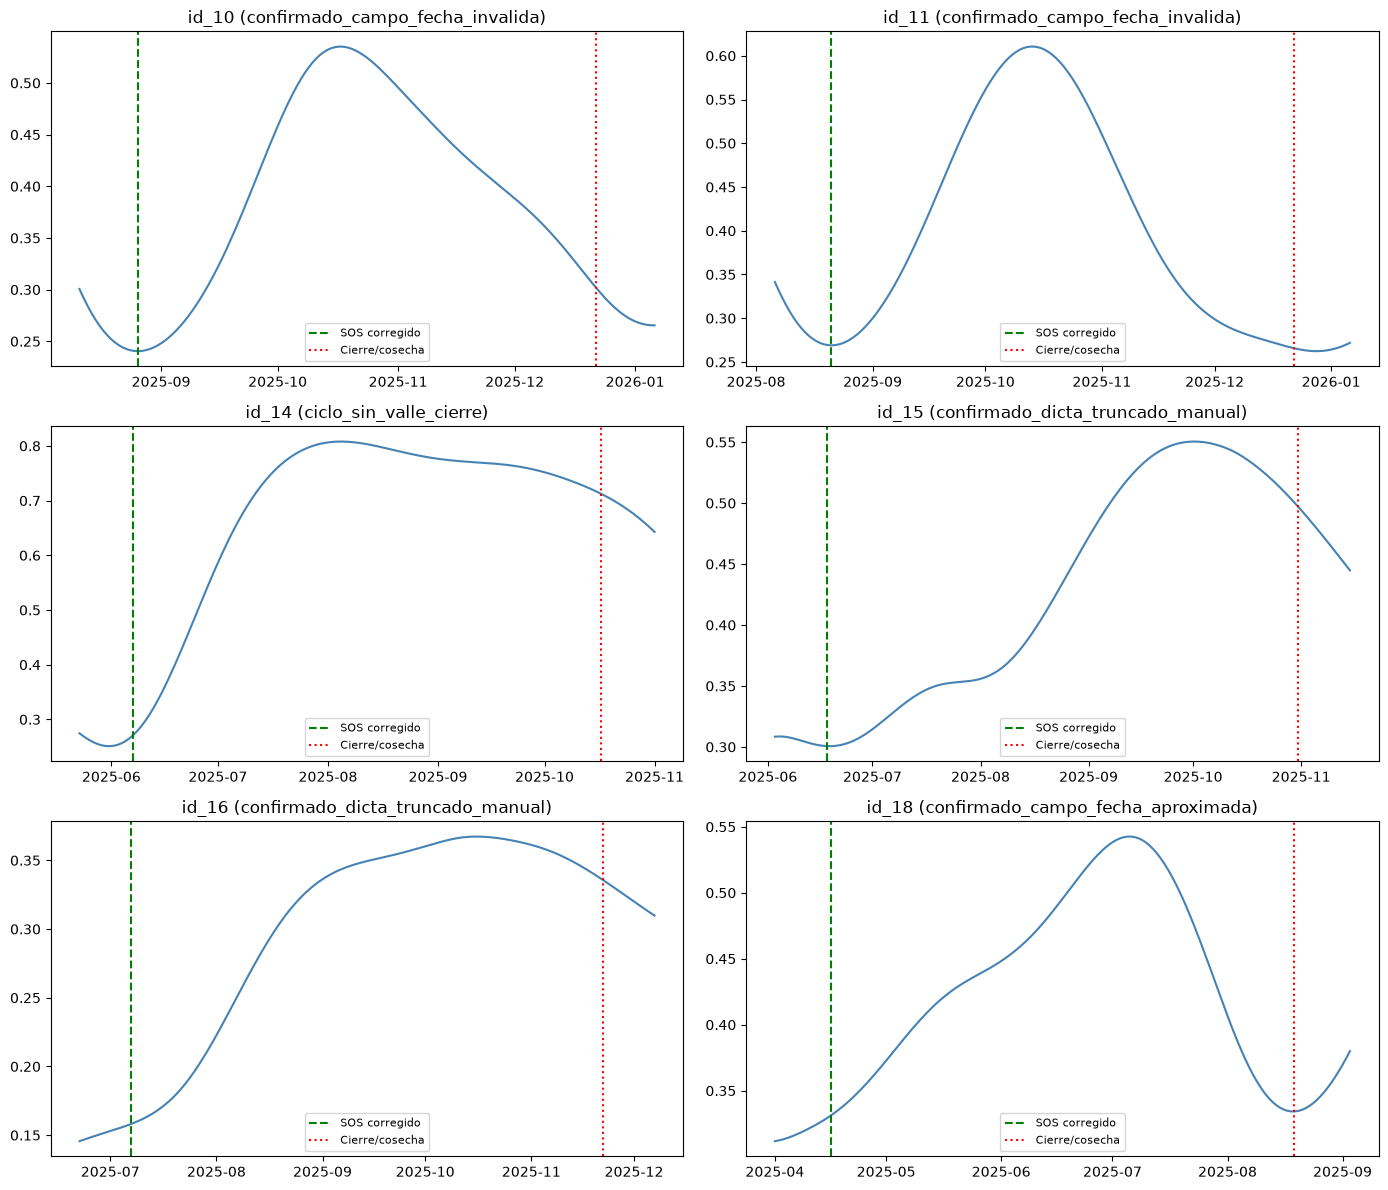

In [20]:
# Celda — Inspección visual de los 6 confirmados de maíz

confirmados_ids = correcciones_manuales.itertuples()

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=False)
axes = axes.flatten()

for ax, corr in zip(axes, correcciones_manuales.itertuples()):
    col = f"id_{corr.id_parcela}"
    sos, fin = corr.sos_confirmado, corr.fin_confirmado
    ventana_amplia = df_evi.loc[sos - pd.Timedelta(days=15): fin + pd.Timedelta(days=15), col]

    ax.plot(ventana_amplia.index, ventana_amplia.values, color="steelblue")
    ax.axvline(sos, color="green", linestyle="--", label="SOS corregido")
    ax.axvline(fin, color="red", linestyle=":", label="Cierre/cosecha")
    ax.set_title(f"id_{corr.id_parcela} ({corr.origen_etiqueta})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [21]:
# Celda — Re-estimar SOS para id_15 e id_16 (detectar arranque real tras meseta residual)

def reestimar_sos_por_umbral(col, sos_original, fin_confirmado, df_evi, factor=0.15, dias_sostenido=5):
    serie = df_evi.loc[sos_original:fin_confirmado, col].dropna()
    baseline = serie.iloc[:15].mean()  # promedio de los primeros ~15 días tras el SOS original (la meseta)
    pico = serie.max()
    umbral = baseline + factor * (pico - baseline)

    sobre_umbral = serie >= umbral
    # exige que se sostenga N días seguidos, no un solo cruce de ruido
    sostenido = sobre_umbral.rolling(dias_sostenido).sum() == dias_sostenido
    candidatos = serie.index[sostenido]

    if len(candidatos) == 0:
        return None
    return candidatos[0] - pd.Timedelta(days=dias_sostenido - 1)


for id_p in [15, 16]:
    corr = correcciones_manuales[correcciones_manuales["id_parcela"] == id_p].iloc[0]
    col = f"id_{id_p}"
    nuevo_sos = reestimar_sos_por_umbral(col, corr["sos_confirmado"], corr["fin_confirmado"], df_evi)
    print(f"id_{id_p}: SOS actual = {corr['sos_confirmado'].date()}  ->  SOS reestimado = {nuevo_sos.date() if nuevo_sos else 'no encontrado'}")

id_15: SOS actual = 2025-06-18  ->  SOS reestimado = 2025-07-14
id_16: SOS actual = 2025-07-07  ->  SOS reestimado = 2025-07-26


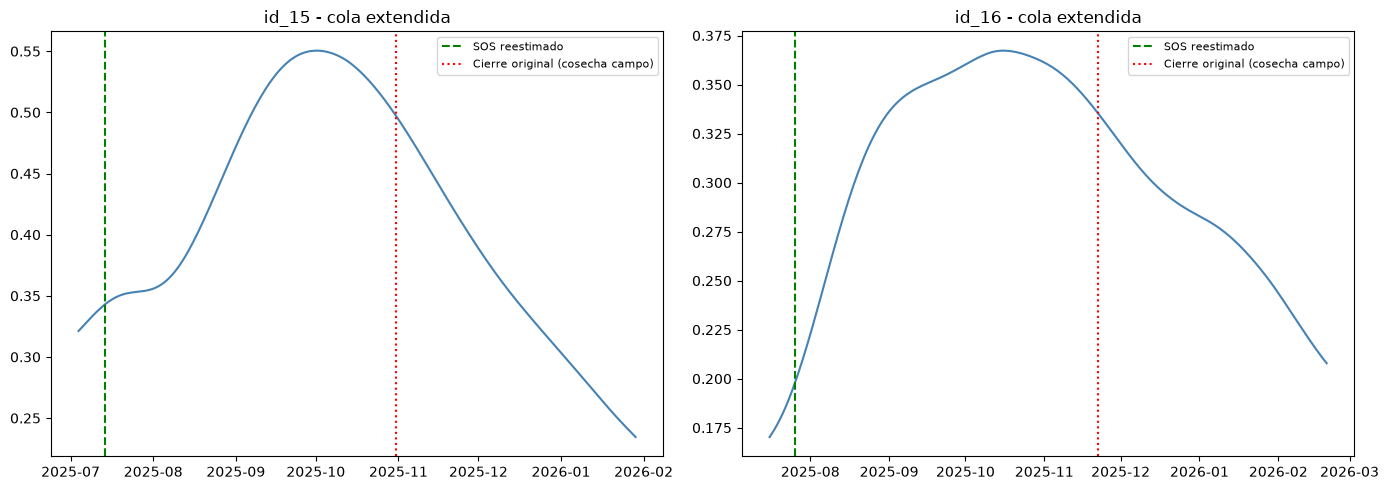

In [22]:
# Celda — Ver la cola completa de descenso para 15 y 16, sin cortar en la cosecha reportada

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, id_p in zip(axes, [15, 16]):
    col = f"id_{id_p}"
    corr = correcciones_manuales[correcciones_manuales["id_parcela"] == id_p].iloc[0]
    sos_reestimado = {15: pd.Timestamp("2025-07-14"), 16: pd.Timestamp("2025-07-26")}[id_p]

    # ventana amplia: desde el SOS reestimado hasta 90 días despues de la cosecha reportada original
    inicio = sos_reestimado - pd.Timedelta(days=10)
    fin_amplio = corr["fin_confirmado"] + pd.Timedelta(days=90)
    serie = df_evi.loc[inicio:fin_amplio, col]

    ax.plot(serie.index, serie.values, color="steelblue")
    ax.axvline(sos_reestimado, color="green", linestyle="--", label="SOS reestimado")
    ax.axvline(corr["fin_confirmado"], color="red", linestyle=":", label="Cierre original (cosecha campo)")
    ax.set_title(f"id_{id_p} - cola extendida")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [23]:
# Celda — Aplicar SOS reestimado a id_15 e id_16 (cierre permanece sin cambio)

nuevos_sos = {15: pd.Timestamp("2025-07-14"), 16: pd.Timestamp("2025-07-26")}

for id_p, nuevo_sos in nuevos_sos.items():
    mask = correcciones_manuales["id_parcela"] == id_p
    correcciones_manuales.loc[mask, "sos_confirmado"] = nuevo_sos
    correcciones_manuales.loc[mask, "justificacion"] += (
        " | SOS reestimado por umbral sostenido tras detectar meseta residual "
        "post-valle de baja prominencia; cierre se mantiene en fecha de cosecha "
        "de campo (no se desplaza, para no incorporar descenso post-cosecha "
        "atribuible a rebrote/maleza, no a fenologia del maiz)."
    )

correcciones_manuales["duracion_dias"] = (
    correcciones_manuales["fin_confirmado"] - correcciones_manuales["sos_confirmado"]
).dt.days

correcciones_manuales[["id_parcela", "sos_confirmado", "fin_confirmado", "duracion_dias", "origen_etiqueta"]]

,id_parcela,sos_confirmado,fin_confirmado,duracion_dias,origen_etiqueta
0,10,2025-08-26,2025-12-22,118,confirmado_campo_fecha_invalida
1,11,2025-08-21,2025-12-22,123,confirmado_campo_fecha_invalida
2,14,2025-06-07,2025-10-17,132,ciclo_sin_valle_cierre
3,15,2025-07-14,2025-10-31,109,confirmado_dicta_truncado_manual
4,16,2025-07-26,2025-11-22,119,confirmado_dicta_truncado_manual
5,18,2025-04-16,2025-08-19,125,confirmado_campo_fecha_aproximada


   k     inercia  silhouette
0  2  260.096276    0.258887
1  3  181.769233    0.302902
2  4  139.098835    0.316692
3  5  115.193297    0.303131
4  6   93.723493    0.331645
5  7   83.656615    0.315010
6  8   70.173408    0.330401


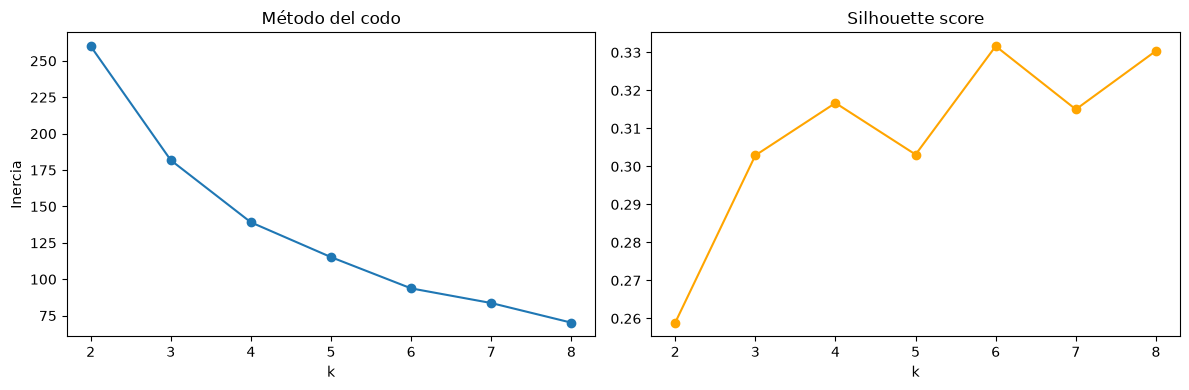

In [27]:
# Celda — Estandarizar descriptores y correr K-Means, con chequeo de circularidad

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

FEATURES = [
    "evi_pico", "dia_pico", "pendiente_verdeo", "pendiente_senescencia",
    "auc_evi", "duracion_meseta", "lswi_min", "lswi_rango",
]

X = tabla_descriptores[FEATURES].copy()
assert X.isna().sum().sum() == 0, "Hay NaN en los descriptores, revisar antes de clusterizar"

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Selección de k: método del codo + silhouette, sobre un rango razonable dado N=45 ---
resultados_k = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inercia = km.inertia_
    sil = silhouette_score(X_scaled, labels)
    resultados_k.append({"k": k, "inercia": inercia, "silhouette": sil})

df_seleccion_k = pd.DataFrame(resultados_k)
print(df_seleccion_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_seleccion_k["k"], df_seleccion_k["inercia"], marker="o")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")

axes[1].plot(df_seleccion_k["k"], df_seleccion_k["silhouette"], marker="o", color="orange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

In [28]:
# Celda — Correr K-Means con el k elegido y chequeo de circularidad

K_ELEGIDO = 6  # <-- ajusta según lo que muestren las gráficas de arriba (codo + silhouette máximo)

km_final = KMeans(n_clusters=K_ELEGIDO, init="k-means++", n_init=10, random_state=42)
tabla_descriptores["cluster"] = km_final.fit_predict(X_scaled)

# --- Chequeo de circularidad: ¿dónde caen los 6 confirmados de maíz? ---
resumen_confirmados = (
    tabla_descriptores[tabla_descriptores["es_confirmado_maiz"]]
    .groupby("cluster")
    .agg(n_confirmados=("id_parcela", "size"), parcelas=("id_parcela", list))
)
print("Distribución de confirmados de maíz por clúster:")
display(resumen_confirmados)

# --- Tamaño total de cada clúster, para ver si los confirmados son mayoría o minoría dentro del suyo ---
resumen_total = tabla_descriptores.groupby("cluster").size().rename("n_total_ciclos")
print("\nTamaño total por clúster:")
display(resumen_total)

# --- Vista completa: qué parcela cayó en qué clúster ---
tabla_descriptores[
    ["id_parcela", "sos_fecha", "duracion_dias", "es_confirmado_maiz", "cluster"]
].sort_values(["cluster", "es_confirmado_maiz"], ascending=[True, False])

Distribución de confirmados de maíz por clúster:


,n_confirmados,parcelas
cluster,,
2,1,[14]
3,4,"[10, 15, 16, 18]"
5,1,[11]



Tamaño total por clúster:


cluster
0     5
1    10
2     4
3    11
4     3
5    12
Name: n_total_ciclos, dtype: int64

,id_parcela,sos_fecha,duracion_dias,es_confirmado_maiz,cluster
0,0,2025-06-02,129,False,0
12,6,2025-05-30,122,False,0
35,13,2025-12-24,144,False,0
36,14,2025-03-28,64,False,0
39,15,2026-04-01,62,False,0
1,0,2025-11-06,125,False,1
4,2,2025-04-27,155,False,1
5,2,2025-12-08,116,False,1
6,3,2025-04-27,152,False,1
7,3,2025-12-08,114,False,1


In [29]:
# Celda — Diagnóstico: valores estandarizados de los 6 confirmados, por feature

idx_confirmados = tabla_descriptores[tabla_descriptores["es_confirmado_maiz"]].index
X_confirmados_scaled = pd.DataFrame(
    X_scaled[tabla_descriptores.index.get_indexer(idx_confirmados)],
    columns=FEATURES,
    index=tabla_descriptores.loc[idx_confirmados, "id_parcela"],
)
X_confirmados_scaled["cluster"] = tabla_descriptores.loc[idx_confirmados, "cluster"].values

pd.set_option("display.float_format", "{:.2f}".format)
X_confirmados_scaled.sort_values("cluster")

,evi_pico,dia_pico,pendiente_verdeo,pendiente_senescencia,auc_evi,duracion_meseta,lswi_min,lswi_rango,cluster
id_parcela,,,,,,,,,
14,1.60,0.30,1.70,-1.54,1.50,1.75,0.42,1.03,2
10,-0.40,-0.04,0.34,-0.60,-0.20,-0.24,0.52,-0.10,3
15,-0.28,1.26,-0.86,-1.35,-0.10,0.34,1.17,-0.65,3
16,-1.63,1.40,-0.68,-1.73,-0.53,1.52,-0.21,-1.13,3
18,-0.34,1.35,-0.84,-0.09,0.07,0.30,0.60,-0.91,3
11,0.16,0.01,0.60,-0.01,-0.07,-0.62,0.93,0.49,5


In [31]:
# Celda — Corregir duracion_meseta a fracción del ciclo y construir ranking de similitud a maíz

tabla_descriptores["duracion_meseta_frac"] = (
    tabla_descriptores["duracion_meseta"] / tabla_descriptores["duracion_dias"]
)

FEATURES_V2 = [
    "evi_pico", "dia_pico", "pendiente_verdeo", "pendiente_senescencia",
    "auc_evi", "duracion_meseta_frac", "lswi_min", "lswi_rango",
]

X_v2 = tabla_descriptores[FEATURES_V2]
scaler_v2 = StandardScaler()
X_v2_scaled = scaler_v2.fit_transform(X_v2)

idx_confirmados = tabla_descriptores[tabla_descriptores["es_confirmado_maiz"]].index
pos_confirmados = tabla_descriptores.index.get_indexer(idx_confirmados)

curva_referencia_maiz = X_v2_scaled[pos_confirmados].mean(axis=0)

from scipy.spatial.distance import cdist
distancias = cdist(X_v2_scaled, curva_referencia_maiz.reshape(1, -1), metric="euclidean").flatten()
tabla_descriptores["distancia_a_maiz"] = distancias

ranking = tabla_descriptores[~tabla_descriptores["es_confirmado_maiz"]].sort_values("distancia_a_maiz")
ranking[["id_parcela", "sos_fecha", "duracion_dias", "distancia_a_maiz"]].head(15)

,id_parcela,sos_fecha,duracion_dias,distancia_a_maiz
23,9,2025-06-25,97,0.86
19,8,2025-07-03,95,1.46
41,17,2025-04-12,114,1.49
28,10,2026-02-01,109,1.75
14,7,2025-03-01,105,1.91
34,13,2025-04-21,236,2.01
15,7,2025-06-30,87,2.17
31,11,2026-01-20,112,2.17
18,8,2025-02-21,112,2.22
2,1,2025-05-27,65,2.47


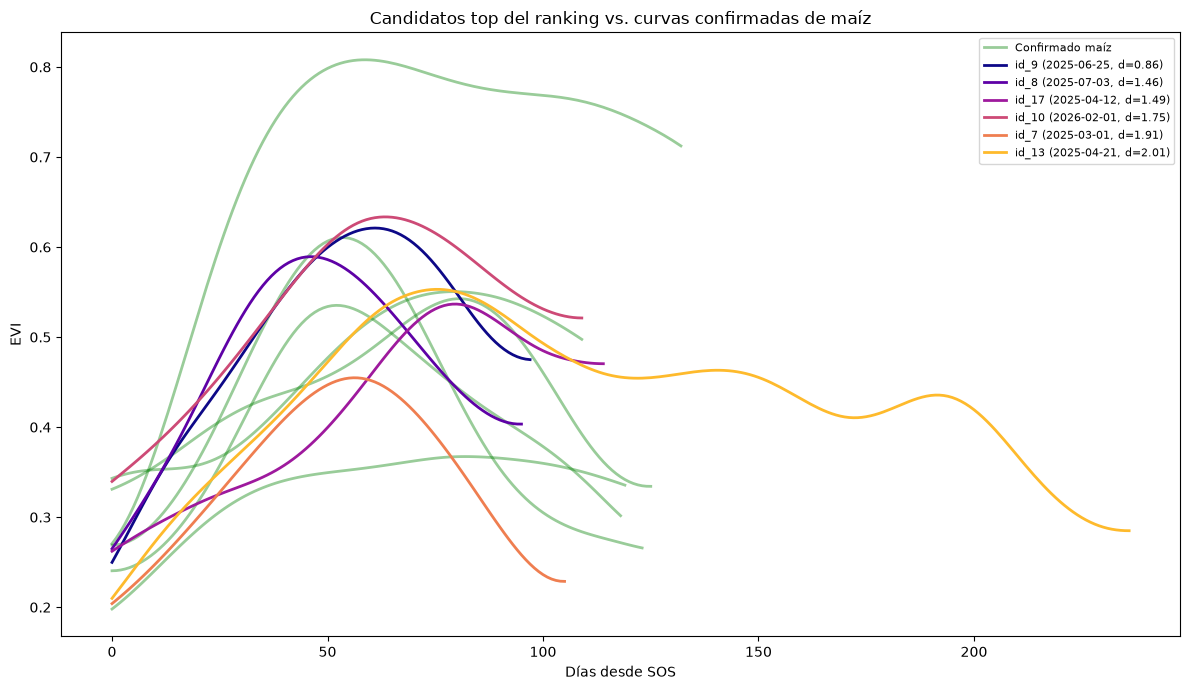

In [32]:
# Celda — Visualizar curvas de los candidatos top del ranking contra la envolvente de confirmados

fig, ax = plt.subplots(figsize=(12, 7))

# Curvas de referencia (confirmados), normalizadas a día-desde-SOS
for _, row in tabla_descriptores[tabla_descriptores["es_confirmado_maiz"]].iterrows():
    col = f"id_{row['id_parcela']}"
    serie = df_evi.loc[row["sos_fecha"]:row["fin_segmento"], col]
    dias = (serie.index - row["sos_fecha"]).days
    ax.plot(dias, serie.values, color="green", alpha=0.4, linewidth=2,
            label="Confirmado maíz" if row.name == tabla_descriptores[tabla_descriptores["es_confirmado_maiz"]].index[0] else None)

# Top 6 candidatos del ranking
colores = plt.cm.plasma(np.linspace(0, 0.85, 6))
top6 = ranking.head(6)
for color, (_, row) in zip(colores, top6.iterrows()):
    col = f"id_{row['id_parcela']}"
    fila_completa = tabla_descriptores.loc[tabla_descriptores["id_parcela"] == row["id_parcela"]]
    fila_completa = fila_completa[fila_completa["sos_fecha"] == row["sos_fecha"]].iloc[0]
    serie = df_evi.loc[fila_completa["sos_fecha"]:fila_completa["fin_segmento"], col]
    dias = (serie.index - fila_completa["sos_fecha"]).days
    ax.plot(dias, serie.values, color=color, linewidth=2,
            label=f"id_{row['id_parcela']} ({row['sos_fecha'].date()}, d={row['distancia_a_maiz']:.2f})")

ax.set_xlabel("Días desde SOS")
ax.set_ylabel("EVI")
ax.set_title("Candidatos top del ranking vs. curvas confirmadas de maíz")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

In [30]:
visualizar_parcelas_hvplot()

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]   (id_parcela)